# ICG for the 300x300 system

In this notebook, we implement the ICG to apply it on the 300x300 system, using the SciPy implementation of the regular CG. 

### Initial data loading

In [2]:
from pathlib import Path
import numpy as np

base_dir = Path("system_303")

A = np.genfromtxt(base_dir / "stiffness_beam_A.dat", delimiter=",")[3:, 3:]
b = np.genfromtxt(base_dir / "forcing_b.dat")[3:]
box = np.genfromtxt(base_dir / "B0_wide_bc.dat", delimiter=",")
x_star = np.genfromtxt(base_dir / "soln_x.dat")[3:]

ell0 = box[3:, 0]
u0 = box[3:, 1]


## Preconditioning

We define $D^{-1/2}$ (`scale`) to be the diagonal entries of $A$. Then,
$\hat{A} = D^{-1/2} A D^{-1/2}$ and $\hat{b} = D^{-1/2} b$, and then to get back to the original solution, you'd do: $x = D^{-1/2} y$

In [3]:
# print the smallest and biggest eigenvals and conditioning number of A, and then of A_hat
diag_A = np.diag(A)
if np.any(diag_A <= 0):
    raise ValueError("Jacobi scaling requires a positive diagonal.")

scale = np.sqrt(diag_A)
A_hat = A / scale[:, None] / scale[None, :]

eigvals_A = np.linalg.eigvalsh(A)
eigvals_A_hat = np.linalg.eigvalsh(A_hat)

condition_A = eigvals_A[-1] / eigvals_A[0]
condition_A_hat = eigvals_A_hat[-1] / eigvals_A_hat[0]

print("A:")
print(f"  smallest eigenvalue: {eigvals_A[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A[-1]:.16e}")
print(f"  condition number:    {condition_A:.16e}")

print("\nA_hat:")
print(f"  smallest eigenvalue: {eigvals_A_hat[0]:.16e}")
print(f"  biggest eigenvalue:  {eigvals_A_hat[-1]:.16e}")
print(f"  condition number:    {condition_A_hat:.16e}")


A:
  smallest eigenvalue: 7.0008220394031389e+02
  biggest eigenvalue:  3.2879900893790034e+12
  condition number:    4.6965771603291941e+09

A_hat:
  smallest eigenvalue: 2.9392884118717852e-08
  biggest eigenvalue:  2.6861406616345080e+00
  condition number:    9.1387447750455067e+07


Using scipy's implementation of the conjugate gradient

SciPy CG info: 0 (0 means converged)
SciPy CG iterations recorded: 1045
SciPy CG final residual norm: 2.689679668114071e-09


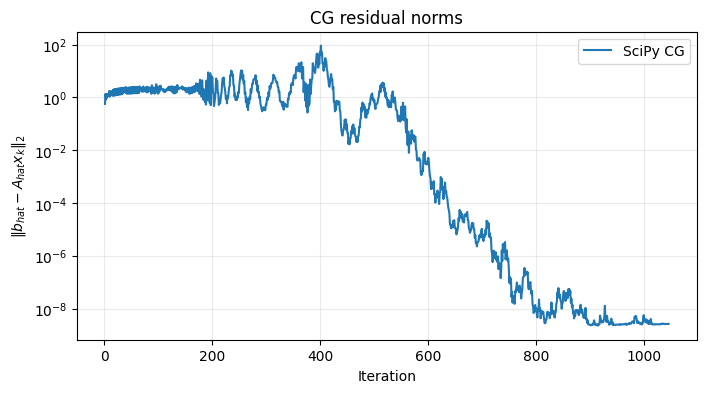

In [4]:
from scipy.sparse.linalg import cg
import matplotlib.pyplot as plt

if "b_hat" not in globals():
    b_hat = b / scale

_cg_A = A_hat
_cg_b = b_hat
_cg_rtol = 1e-10
_cg_atol = 0.0
_cg_maxiter = 10_000

scipy_residual_norms = []


def record_scipy_residual(xk):
    scipy_residual_norms.append(np.linalg.norm(_cg_b - _cg_A @ xk))


x_scipy_cg, scipy_cg_info = cg(
    _cg_A,
    _cg_b,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=_cg_maxiter,
    callback=record_scipy_residual,
)

print("SciPy CG info:", scipy_cg_info, "(0 means converged)")
print("SciPy CG iterations recorded:", len(scipy_residual_norms))
print("SciPy CG final residual norm:", scipy_residual_norms[-1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} x_k\|_2$")
ax.set_title("CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


More or less, copy paste of the scipy implementation, except we record the search directions too. 

In [5]:
def cg_with_direction_callback(
    A,
    b,
    x0=None,
    rtol=1e-8,
    atol=0.0,
    maxiter=None,
    M=None,
    callback=None,
    direction_callback=None,
):
    b = np.asarray(b)
    n = b.shape[0]
    x = np.zeros_like(b) if x0 is None else np.array(x0, dtype=b.dtype, copy=True)

    def matvec(v):
        if callable(A):
            return np.asarray(A(v))
        if hasattr(A, "matvec"):
            return np.asarray(A.matvec(v))
        return np.asarray(A @ v)

    def psolve(v):
        if M is None:
            return v.copy()
        if callable(M):
            return np.asarray(M(v))
        if hasattr(M, "matvec"):
            return np.asarray(M.matvec(v))
        return np.asarray(M @ v)

    if maxiter is None:
        maxiter = n * 10

    bnrm2 = np.linalg.norm(b)
    atol_threshold = max(float(atol), float(rtol) * bnrm2)

    r = b - matvec(x) if x0 is not None else b.copy()
    if np.linalg.norm(r) < atol_threshold:
        return x, 0

    rho_prev = None
    p = None

    for k in range(maxiter):
        z = psolve(r)
        rho_cur = np.dot(r, z)

        if k > 0:
            beta = rho_cur / rho_prev
            p = z + beta * p
        else:
            p = z.copy()

        q = matvec(p)
        if direction_callback is not None:
            direction_callback(k, x.copy(), r.copy(), p.copy(), q.copy())

        alpha = rho_cur / np.dot(p, q)
        x += alpha * p
        r -= alpha * q

        if callback is not None:
            callback(x.copy())

        if np.linalg.norm(r) < atol_threshold:
            return x, 0

        rho_prev = rho_cur

    return x, maxiter


Custom CG info: 0 (0 means converged)
Custom CG iterations recorded: 1045
Custom CG final residual norm: 2.689679668114071e-09
P_cg shape: (1045, 300)
Q_cg shape: (1045, 300)
c_cg shape: (1045,)


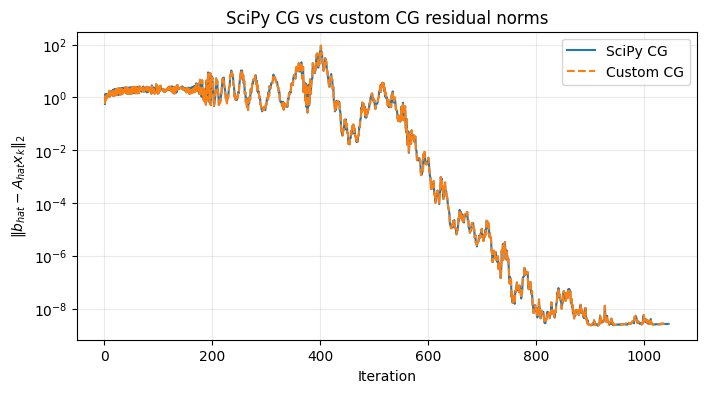

In [6]:
custom_residual_norms = []
p_list = []
q_list = []
c_list = []


def record_custom_residual(xk):
    custom_residual_norms.append(np.linalg.norm(_cg_b - _cg_A @ xk))


def record_direction(k, x, r, p, q):
    p_list.append(p)
    q_list.append(q)
    c_list.append(np.dot(p, _cg_b))


x_custom_cg, custom_cg_info = cg_with_direction_callback(
    _cg_A,
    _cg_b,
    rtol=_cg_rtol,
    atol=_cg_atol,
    maxiter=_cg_maxiter,
    callback=record_custom_residual,
    direction_callback=record_direction,
)

P_cg = np.vstack(p_list)
Q_cg = np.vstack(q_list)
c_cg = np.array(c_list)

print("Custom CG info:", custom_cg_info, "(0 means converged)")
print("Custom CG iterations recorded:", len(custom_residual_norms))
print("Custom CG final residual norm:", custom_residual_norms[-1])
print("P_cg shape:", P_cg.shape)
print("Q_cg shape:", Q_cg.shape)
print("c_cg shape:", c_cg.shape)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(range(1, len(scipy_residual_norms) + 1), scipy_residual_norms, label="SciPy CG")
ax.semilogy(
    range(1, len(custom_residual_norms) + 1),
    custom_residual_norms,
    "--",
    label="Custom CG",
)
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\|b_{hat} - A_{hat} x_k\|_2$")
ax.set_title("SciPy CG vs custom CG residual norms")
ax.grid(alpha=0.25, which="both")
ax.legend()
plt.show()


In [7]:
import numpy as np

# Q_cg has shape (1045, 300)
s = np.linalg.svd(Q_cg, compute_uv=False)

print("Q_cg shape:", Q_cg.shape)
print("Largest singular value:", s[0])
print("Smallest singular value:", s[-1])

for tol in [1e-8, 1e-10, 1e-12, 1e-14]:
    rank = np.sum(s > tol * s[0])
    print(f"relative tol {tol:g}: numerical rank = {rank}")

Q_cg shape: (1045, 300)
Largest singular value: 56.985646450405916
Smallest singular value: 0.0
relative tol 1e-08: numerical rank = 200
relative tol 1e-10: numerical rank = 200
relative tol 1e-12: numerical rank = 200
relative tol 1e-14: numerical rank = 200


In [8]:
constraint_residual = Q_cg @ x_custom_cg - c_cg

print("max constraint residual:", np.max(np.abs(constraint_residual)))
print("norm constraint residual:", np.linalg.norm(constraint_residual))
print("relative constraint residual:",
      np.linalg.norm(constraint_residual) / np.linalg.norm(c_cg))

max constraint residual: 1.4768506844120566e-06
norm constraint residual: 3.035702805913046e-06
relative constraint residual: 3.021645920418708e-10


## Box Minimization

In [9]:
import numpy as np
from scipy.linalg import qr
from scipy.optimize import linprog

row_norms = np.linalg.norm(Q_cg, axis=1)
nonzero = row_norms > 0

Qn_all = Q_cg[nonzero] / row_norms[nonzero, None]
cn_all = c_cg[nonzero] / row_norms[nonzero]

QT = Qn_all.T

_, R, piv = qr(QT, pivoting=True, mode="economic")

diag_R = np.abs(np.diag(R))
tol = 1e-10 * diag_R[0]

rank = int(np.sum(diag_R > tol))
selected = piv[:rank]

Q_ind = Qn_all[selected]
c_ind = cn_all[selected]

print("Selected rank:", rank)
print("Q_ind shape:", Q_ind.shape)

Selected rank: 200
Q_ind shape: (200, 300)


In [10]:
constraint_residual_ind = Q_ind @ x_custom_cg - c_ind

print("max selected normalized residual:",
      np.max(np.abs(constraint_residual_ind)))

print("norm selected normalized residual:",
      np.linalg.norm(constraint_residual_ind))

max selected normalized residual: 1.4521958746627206e-08
norm selected normalized residual: 3.165886658241505e-08


In [11]:
observed_tau = np.max(np.abs(constraint_residual_ind))

tau = max(10.0 * observed_tau, 1e-10)

print("Using tau:", tau)

Using tau: 1.4521958746627206e-07


In [12]:
# If scale = sqrt(diag(A_original))
ell_hat = scale * ell0
u_hat = scale * u0

In [13]:
def coordinate_bounds_from_relaxed_constraints(Q, c, ell, u, tau, highs_method="highs"):
    n = len(ell)

    A_ub = np.vstack([Q, -Q])
    b_ub = np.concatenate([c + tau, -c + tau])

    bounds = list(zip(ell, u))

    ell_new = np.empty(n)
    u_new = np.empty(n)

    for i in range(n):
        obj = np.zeros(n)
        obj[i] = 1.0

        res_min = linprog(
            obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=highs_method,
        )

        if not res_min.success:
            raise RuntimeError(f"Min LP failed at coordinate {i}: {res_min.message}")

        ell_new[i] = res_min.fun

        res_max = linprog(
            -obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=highs_method,
        )

        if not res_max.success:
            raise RuntimeError(f"Max LP failed at coordinate {i}: {res_max.message}")

        u_new[i] = -res_max.fun

    return ell_new, u_new

ell_y, u_y = coordinate_bounds_from_relaxed_constraints(
    Q=Q_ind,
    c=c_ind,
    ell=ell_hat,
    u=u_hat,
    tau=tau,
)

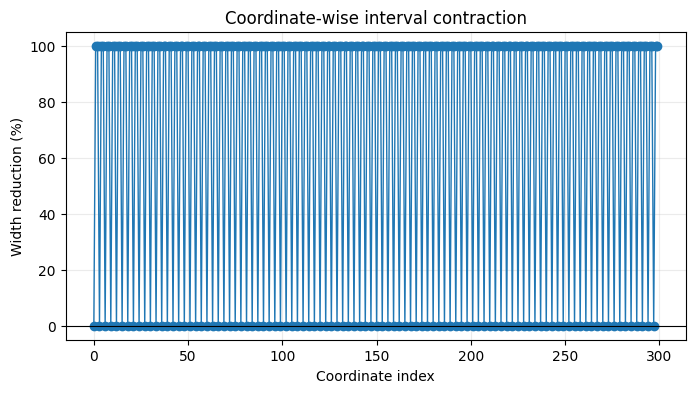

mean contraction %: 66.66666595567663
median contraction %: 99.99999810982521
min contraction %: -2.220446049250313e-14
max contraction %: 99.99999999957556


In [14]:
ell_x = ell_y / scale
u_x = u_y / scale

# initial_width = u_hat - ell_hat
# final_width = u_y - ell_y

# contraction_ratio = final_width / initial_width

initial_width = u0 - ell0
final_width = u_x - ell_x

contraction_ratio = final_width / initial_width

with np.errstate(divide="ignore", invalid="ignore"):
    contraction_pct = 100 * (1 - final_width / initial_width)

plt.figure(figsize=(8, 4))
plt.plot(contraction_pct[:300], marker="o", linewidth=1)
plt.axhline(0, color="black", linewidth=0.8)
plt.xlabel("Coordinate index")
plt.ylabel("Width reduction (%)")
plt.title("Coordinate-wise interval contraction")
plt.grid(alpha=0.25)
plt.show()

print("mean contraction %:", np.nanmean(contraction_pct))
print("median contraction %:", np.nanmedian(contraction_pct))
print("min contraction %:", np.nanmin(contraction_pct))
print("max contraction %:", np.nanmax(contraction_pct))

## Animation 

In [17]:
def independent_normalized_constraints_through_iteration(iteration, qr_tol=1e-10):
    mask = constraint_iterations_all <= iteration
    Qn_iter = Qn_all[mask]
    cn_iter = cn_all[mask]

    if Qn_iter.size == 0:
        return Qn_iter.reshape(0, len(ell_hat)), cn_iter

    _, R_iter, piv_iter = qr(Qn_iter.T, pivoting=True, mode="economic")
    diag_R_iter = np.abs(np.diag(R_iter))

    if diag_R_iter.size == 0 or diag_R_iter[0] == 0:
        return Qn_iter[:0], cn_iter[:0]

    rank_iter = int(np.sum(diag_R_iter > qr_tol * diag_R_iter[0]))
    selected_iter = piv_iter[:rank_iter]

    return Qn_iter[selected_iter], cn_iter[selected_iter]


def _linprog_with_fallback(obj, A_ub, b_ub, bounds, label, coordinate):
    attempts = [
        ("highs", None),
        ("highs-ds", None),
        ("highs-ipm", None),
        ("highs", {"presolve": False}),
        ("highs-ds", {"presolve": False}),
    ]
    last_res = None

    for method, options in attempts:
        res = linprog(
            obj,
            A_ub=A_ub,
            b_ub=b_ub,
            bounds=bounds,
            method=method,
            options=options,
        )
        if res.success and np.isfinite(res.fun):
            return res
        last_res = res

    raise RuntimeError(
        f"{label} LP failed at coordinate {coordinate}: {last_res.message}"
    )


def coordinate_bounds_from_relaxed_constraints_unit_box(Q, c, ell, u, tau):
    ell = np.asarray(ell, dtype=float)
    u = np.asarray(u, dtype=float)
    widths = u - ell
    free = widths > 0

    ell_new = ell.copy()
    u_new = u.copy()

    if not np.any(free):
        return ell_new, u_new

    free_indices = np.flatnonzero(free)
    constant_part = Q @ ell
    Q_scaled = Q[:, free] * widths[free][None, :]

    A_ub = np.vstack([Q_scaled, -Q_scaled])
    b_ub = np.concatenate([
        c + tau - constant_part,
        -c + tau + constant_part,
    ])

    row_norms = np.linalg.norm(A_ub, axis=1)
    zero_rows = row_norms == 0
    if np.any(zero_rows & (b_ub < -1e-12)):
        raise RuntimeError("Infeasible zero-row constraint in snapshot LP.")

    keep_rows = row_norms > 0
    A_ub = A_ub[keep_rows] / row_norms[keep_rows, None]
    b_ub = b_ub[keep_rows] / row_norms[keep_rows]

    bounds = [(0.0, 1.0)] * len(free_indices)

    for local_i, coordinate in enumerate(free_indices):
        obj = np.zeros(len(free_indices))
        obj[local_i] = 1.0

        res_min = _linprog_with_fallback(
            obj, A_ub, b_ub, bounds, "Min", coordinate
        )
        res_max = _linprog_with_fallback(
            -obj, A_ub, b_ub, bounds, "Max", coordinate
        )

        z_min = np.clip(res_min.fun, 0.0, 1.0)
        z_max = np.clip(-res_max.fun, 0.0, 1.0)
        ell_new[coordinate] = ell[coordinate] + widths[coordinate] * z_min
        u_new[coordinate] = ell[coordinate] + widths[coordinate] * z_max

    return ell_new, u_new


total_cg_iterations = len(Q_cg)
constraint_iterations_all = np.flatnonzero(nonzero) + 1

box_snapshot_iterations = np.arange(10, total_cg_iterations + 1, 10)
if box_snapshot_iterations[-1] != total_cg_iterations:
    box_snapshot_iterations = np.append(box_snapshot_iterations, total_cg_iterations)

minimized_boxes_by_iteration = np.empty(
    (len(box_snapshot_iterations), len(ell0), 2),
    dtype=float,
)
selected_constraint_counts = np.empty(len(box_snapshot_iterations), dtype=int)

for snapshot_idx, iteration in enumerate(box_snapshot_iterations):
    Q_iter, c_iter = independent_normalized_constraints_through_iteration(iteration)
    selected_constraint_counts[snapshot_idx] = len(c_iter)

    if len(c_iter) == 0:
        ell_x_iter = ell0.copy()
        u_x_iter = u0.copy()
    elif iteration == total_cg_iterations and "ell_y" in globals() and "u_y" in globals():
        ell_x_iter = ell_y / scale
        u_x_iter = u_y / scale
    else:
        ell_y_iter, u_y_iter = coordinate_bounds_from_relaxed_constraints_unit_box(
            Q=Q_iter,
            c=c_iter,
            ell=ell_hat,
            u=u_hat,
            tau=tau,
        )
        ell_x_iter = ell_y_iter / scale
        u_x_iter = u_y_iter / scale

    minimized_boxes_by_iteration[snapshot_idx, :, 0] = ell_x_iter
    minimized_boxes_by_iteration[snapshot_idx, :, 1] = u_x_iter

    print(
        f"{snapshot_idx + 1:3d}/{len(box_snapshot_iterations)}: "
        f"iteration {iteration}, selected constraints {len(c_iter)}"
    )

np.save(base_dir / "minimized_boxes_by_iteration.npy", minimized_boxes_by_iteration)
np.save(base_dir / "box_snapshot_iterations.npy", box_snapshot_iterations)
np.save(base_dir / "selected_constraint_counts.npy", selected_constraint_counts)

print("minimized_boxes_by_iteration shape:", minimized_boxes_by_iteration.shape)
print("saved to:", base_dir / "minimized_boxes_by_iteration.npy")

  1/105: iteration 10, selected constraints 10
  2/105: iteration 20, selected constraints 20
  3/105: iteration 30, selected constraints 30
  4/105: iteration 40, selected constraints 40
  5/105: iteration 50, selected constraints 50
  6/105: iteration 60, selected constraints 58
  7/105: iteration 70, selected constraints 68
  8/105: iteration 80, selected constraints 78
  9/105: iteration 90, selected constraints 87
 10/105: iteration 100, selected constraints 96
 11/105: iteration 110, selected constraints 106
 12/105: iteration 120, selected constraints 114
 13/105: iteration 130, selected constraints 122
 14/105: iteration 140, selected constraints 132
 15/105: iteration 150, selected constraints 141
 16/105: iteration 160, selected constraints 150
 17/105: iteration 170, selected constraints 160
 18/105: iteration 180, selected constraints 169
 19/105: iteration 190, selected constraints 176
 20/105: iteration 200, selected constraints 183
 21/105: iteration 210, selected constr

In [18]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

mod3_indices = np.arange(minimized_boxes_by_iteration.shape[1])
mod3_indices = mod3_indices[mod3_indices % 3 == 1]

tracked_widths = (
    minimized_boxes_by_iteration[:, mod3_indices, 1]
    - minimized_boxes_by_iteration[:, mod3_indices, 0]
)

with np.errstate(divide="ignore", invalid="ignore"):
    tracked_shrinkage_pct = 100 * (
        1 - tracked_widths / initial_width[mod3_indices][None, :]
    )

finite_shrinkage = tracked_shrinkage_pct[np.isfinite(tracked_shrinkage_pct)]
y_min = min(0.0, np.nanmin(finite_shrinkage))
y_max = max(100.0, np.nanmax(finite_shrinkage))
y_pad = 0.05 * max(1.0, y_max - y_min)

fig, ax = plt.subplots(figsize=(9, 4.5))
line, = ax.plot(
    mod3_indices,
    tracked_shrinkage_pct[0],
    marker="o",
    markersize=3,
    linewidth=1,
)
title = ax.set_title(
    f"1 mod 3 coordinate shrinkage at iteration {box_snapshot_iterations[0]}"
)
ax.set_xlabel("Coordinate index (i % 3 == 1)")
ax.set_ylabel("Width reduction (% of original width)")
ax.set_ylim(y_min - y_pad, y_max + y_pad)
ax.grid(alpha=0.25)


def update_shrinkage(frame):
    line.set_ydata(tracked_shrinkage_pct[frame])
    title.set_text(
        f"1 mod 3 coordinate shrinkage at iteration {box_snapshot_iterations[frame]}"
    )
    return line, title


shrinkage_animation = FuncAnimation(
    fig,
    update_shrinkage,
    frames=len(box_snapshot_iterations),
    interval=200,
    blit=False,
)

plt.close(fig)
HTML(shrinkage_animation.to_jshtml())